# Grad-CAM

Gradient-weighted Class Activation Mapping

“For this image and this predicted class, where in the image did the CNN get its evidence?”

In [10]:
import tensorflow as tf
from os import getcwd
from pathlib import Path

# array of the classes as represented in the model
CLASS_NAMES = [
    "Black Sea Sprat",      # 0
    "Gilt-Head Bream",      # 1
    "Hourse Mackerel",      # 2
    "Red Mullet",           # 3
    "Red Sea Bream",        # 4
    "Sea Bass",             # 5
    "Shrimp",               # 6
    "Striped Red Mullet",   # 7
    "Trout",                # 8
]

# The model that will be evaluated
print(Path(getcwd()).resolve())
model = tf.keras.models.load_model("/home/groggy/projects/Image-Classification-Explainability/ML/Models/MobileNetV3Large_Improved.keras")



"""
If you wish to use a random image you can use random_img_path
If you want to use a misclassified image you can use random_misclassified_img_path
If you want to use a specific image you can use img_path
"""
from gather_image import get_random_image_path, find_misclassified_image
DATASET_FOLDER = "/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset"

random_img_path = get_random_image_path(DATASET_FOLDER, CLASS_NAMES)
print(f"Random image: {random_img_path}")

result = find_misclassified_image(model, CLASS_NAMES, DATASET_FOLDER)
if result:
    random_misclassified_img_path = result["img_path"]
else:
    #Fallback to a misclassified image in case none is found
    random_misclassified_img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Gilt-Head Bream/Gilt-Head Bream/00894.png"

# The image that will be valuated. can be changed manually
img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/urelaterte_bilder/1280px-Penaeus_monodon.jpg"


# comment out to use what you choose
#img_path = random_img_path
img_path = random_misclassified_img_path





/home/groggy/projects/Image-Classification-Explainability/ML
Random image: /home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Shrimp/Shrimp/00567.png
  ... tried 50 images, still searching...
  ... tried 100 images, still searching...
  ... tried 150 images, still searching...
✓ Found misclassification after 178 attempts!
  True: Sea Bass (class 5)
  Predicted: Trout (class 8)
  Confidence: 44.13%
  Path: /home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Sea Bass/Sea Bass/00881.png


## Compare Grad_CAM with only the predicted class

What we see is:
* Original image
* Heatmap
* * Hot/warm colors (red/yellow) = regions that most influenced the model’s score for the chosen class
* * Cool/dark colors (blue/purple) = regions that contributed less
* Overlay heatmap on image
* * The heatmap is blended onto the original so you can interpret it visually.

/home/groggy/.virtualenvs/Image-Classification-Explainability/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Saved to images/Grad-cam_vs_predicted_class.png


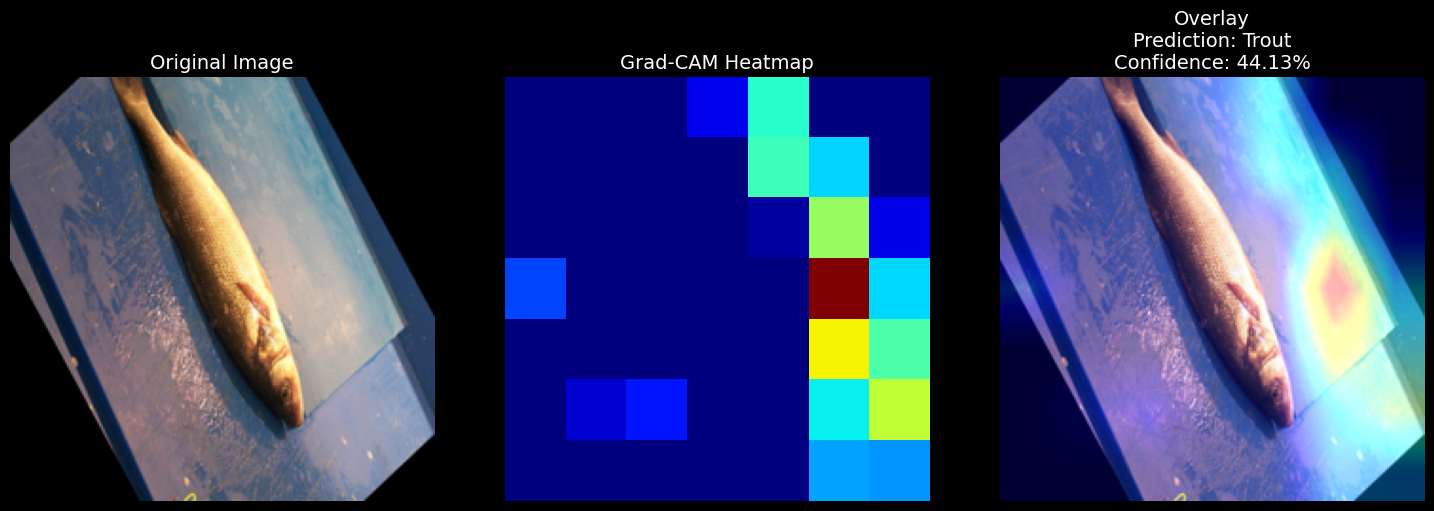

Saved to images/Grad-cam_vs_true_class.png


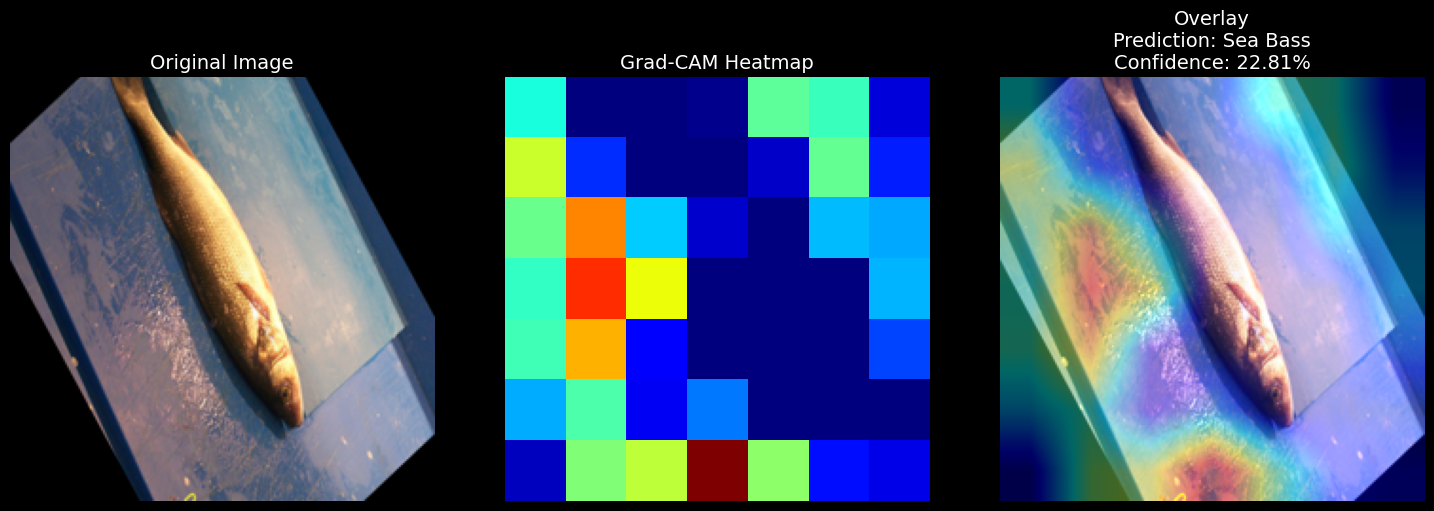

True class: Sea Bass
Predicted class: Trout


In [11]:
from gradcam_single_image_v3 import visualize_gradcam

# Visualize predicted class
img, heatmap, overlay_img, pred_class_idx = visualize_gradcam(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path="images/Grad-cam_vs_predicted_class.png"
)

# Visualize true class
true_class_idx = CLASS_NAMES.index(img_path.split("/")[-3])
img, heatmap, overlay_img, _ = visualize_gradcam(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    class_index=true_class_idx,
    save_path="images/Grad-cam_vs_true_class.png"
)

print(f"True class: {img_path.split('/')[-3]}")
print(f"Predicted class: {CLASS_NAMES[pred_class_idx]}")

## Compare with all 9 classes

Instead of just comparing with the top1 class we compare with all the 9 classes and see what the model lookls at for each class

Model predicts: Trout (class 8) with 44.13% confidence
Saved to images/Grad-cam_vs_all_classes_grid.png


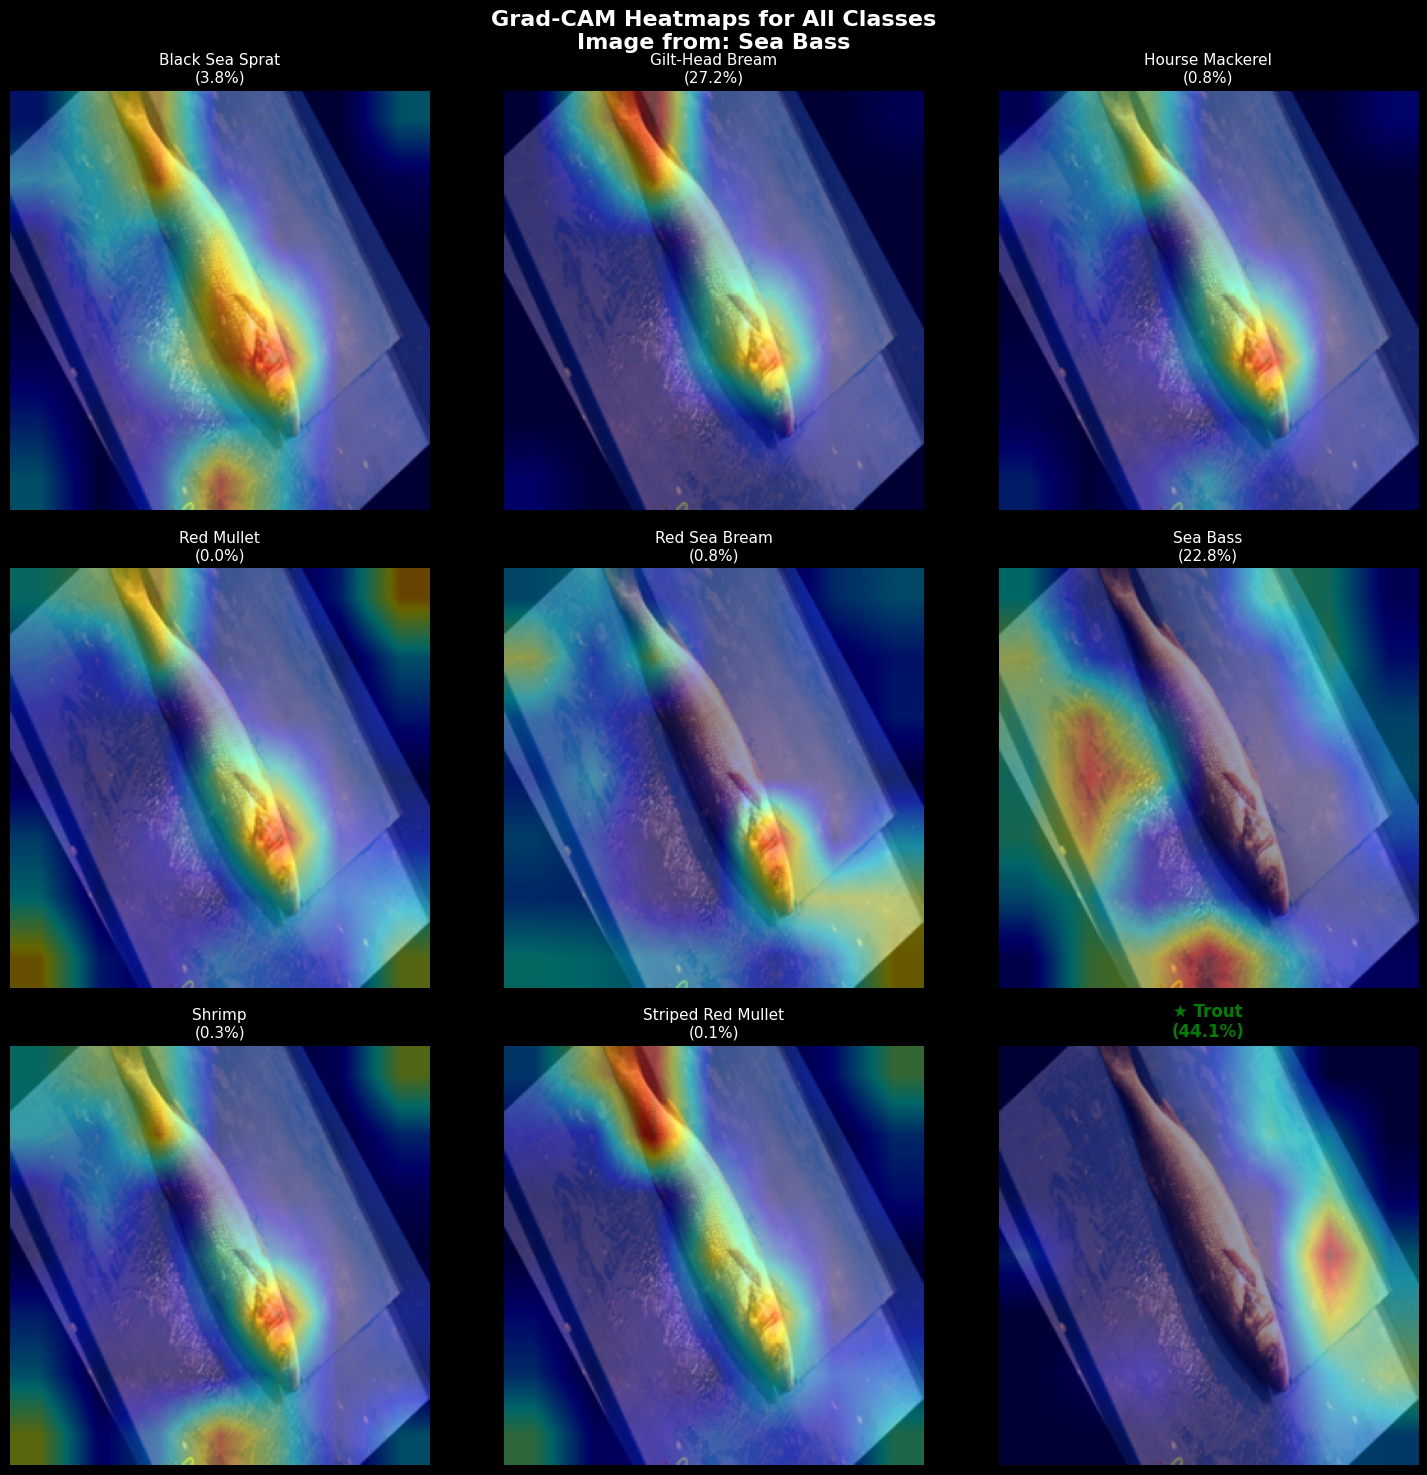


★ = Predicted class: Trout
Predicted: class Trout
True class: Sea Bass
Confidence: 44.13%


In [12]:
from gradcam_all_classes_v3 import visualize_gradcam_all_classes

result = visualize_gradcam_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path='images/Grad-cam_vs_all_classes_grid.png'
)

# Access the results
print(f"Predicted: class {CLASS_NAMES[result['predicted_class']]}")
print(f"True class: {img_path.split('/')[-3]}")
print(f"Confidence: {result['probabilities'][result['predicted_class']]:.2%}")

# Integrated gradient

compare with predicted class:
Saved to images/ig_vs_predicted_class.png


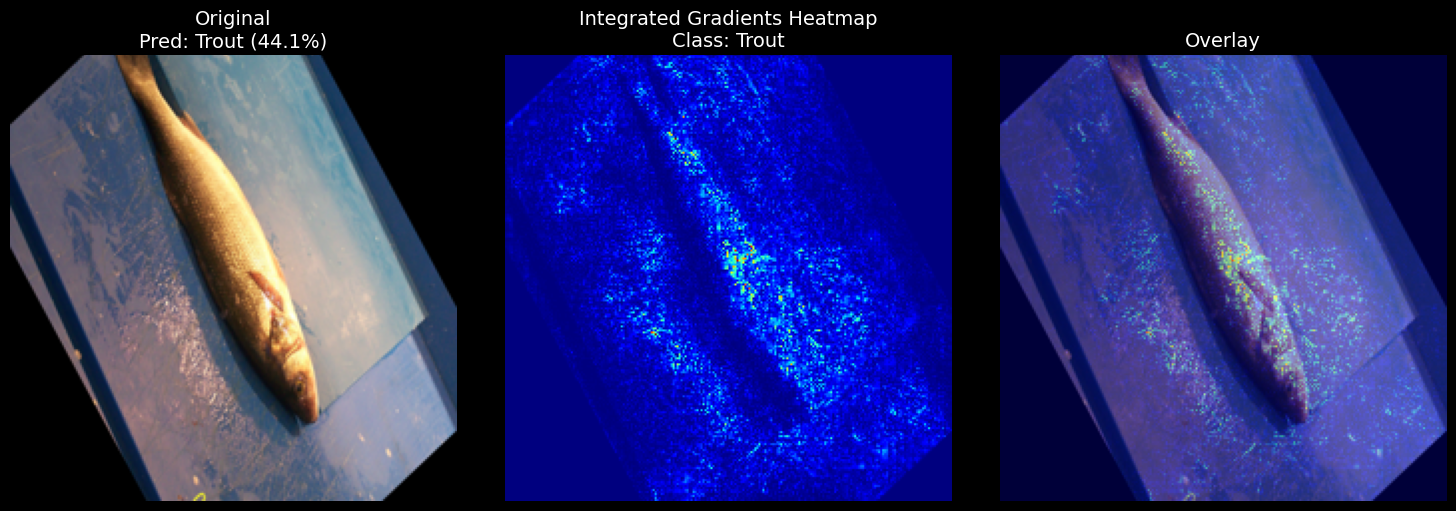

compare with true class: 5
Saved to images/ig_vs_true_class.png


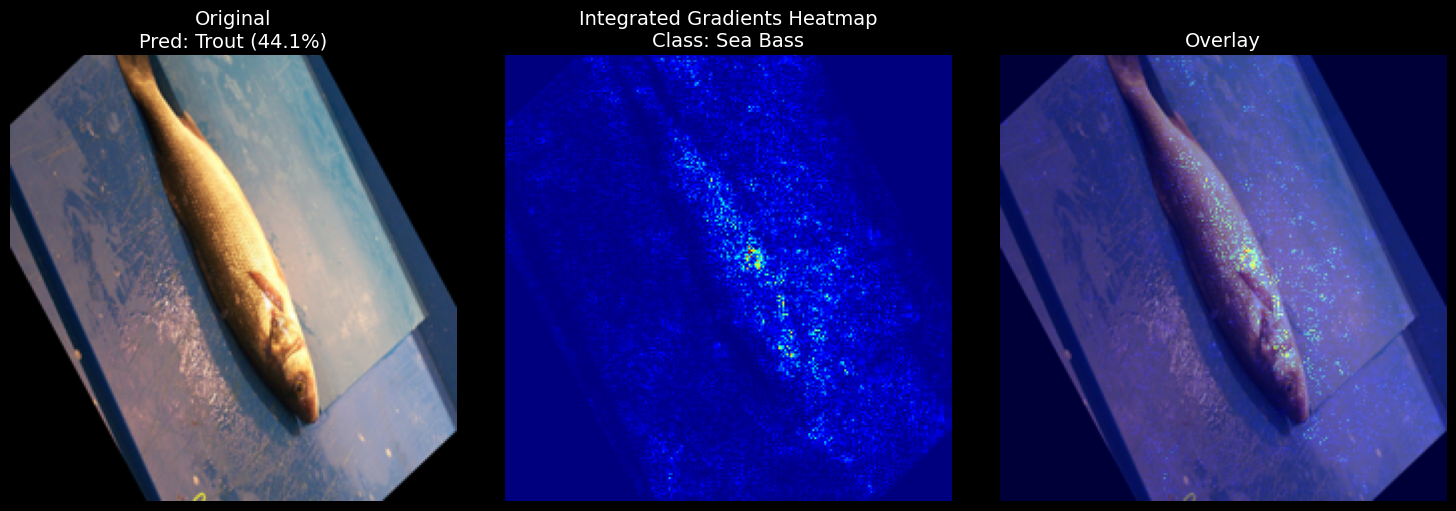

In [13]:
from integrated_gradients_single_image_v3 import visualize_integrated_gradients

print("compare with predicted class:")
img, heatmap, overlay_img, class_idx = visualize_integrated_gradients(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path="images/ig_vs_predicted_class.png",
    steps=25
)

# Force a specific class
print("compare with true class:", CLASS_NAMES.index(img_path.split("/")[-3]))
img, heatmap, overlay_img, class_idx = visualize_integrated_gradients(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    target_class_idx=true_class_idx,
    save_path="images/ig_vs_true_class.png",
    steps=25
)


Predicted: Trout (class 8) prob=44.13%
Saved to images/ig_vs_all_classes_grid.png


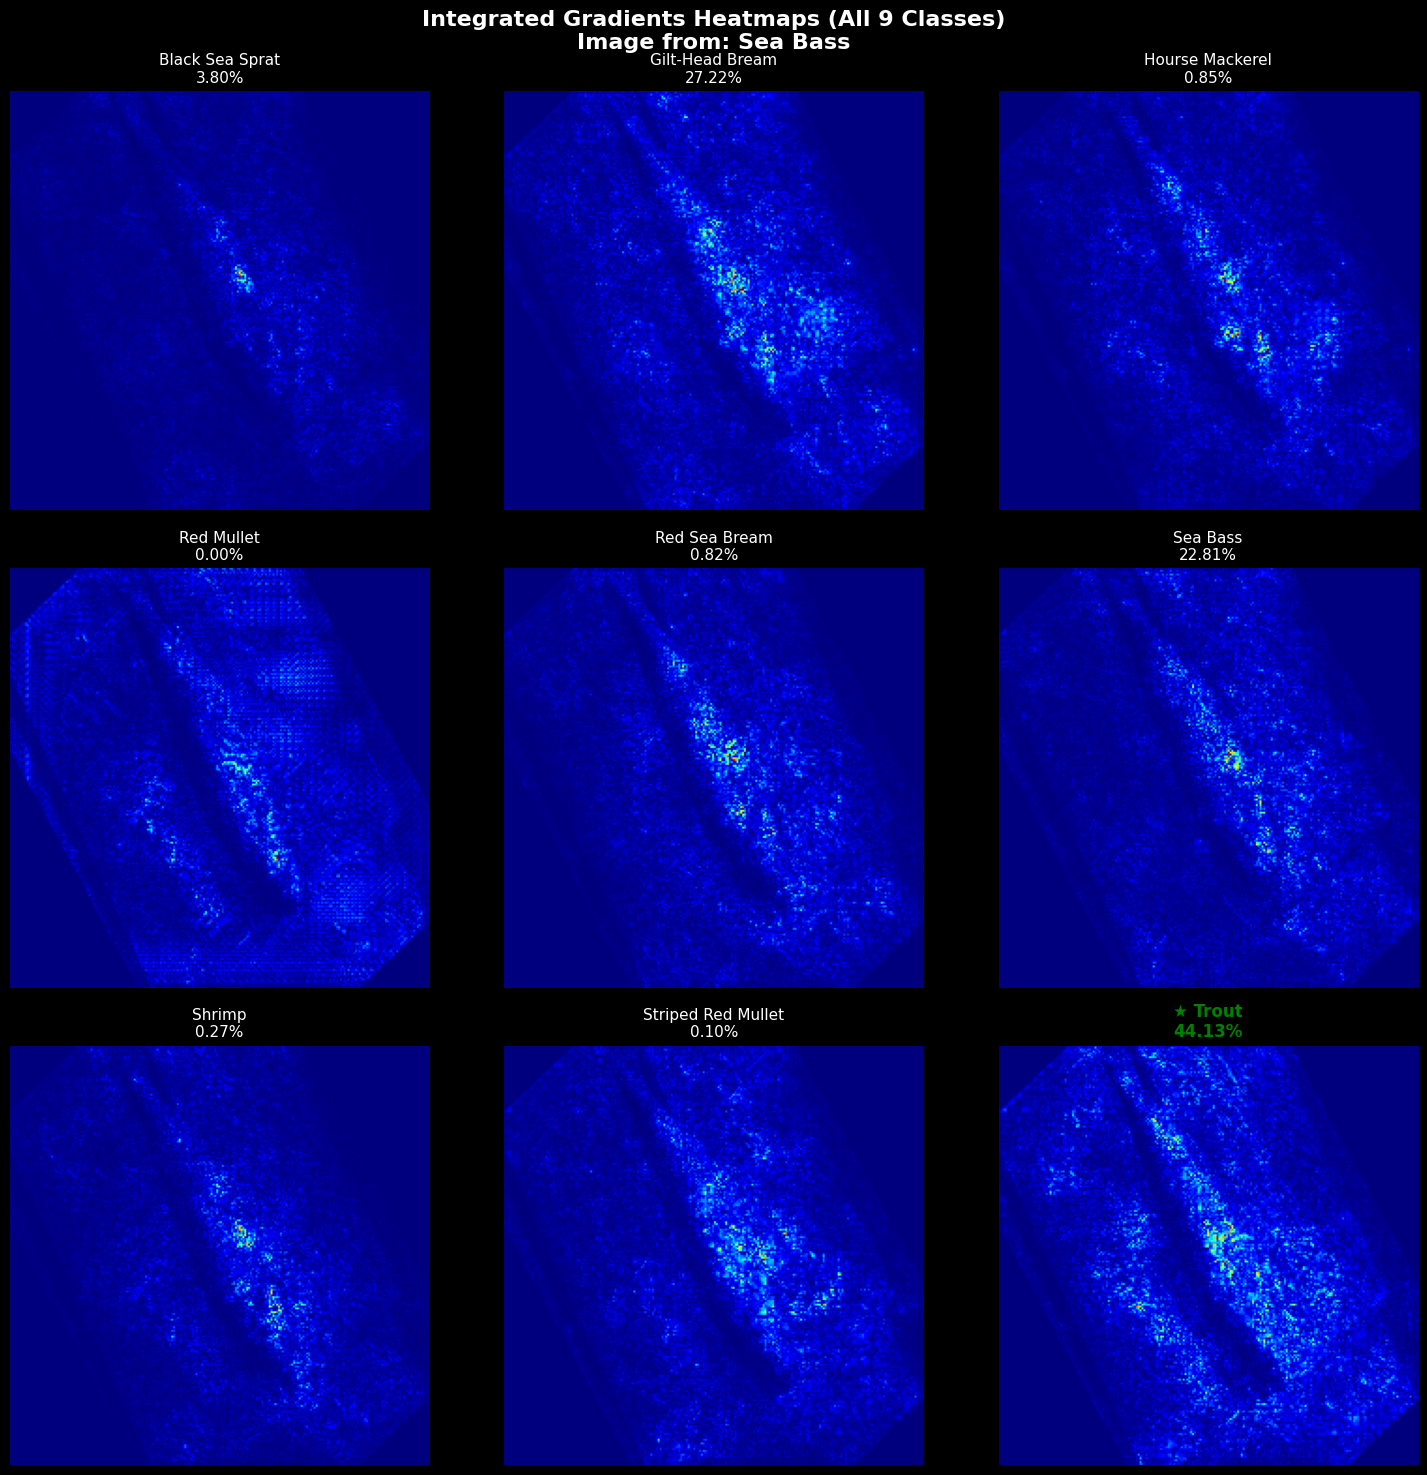


★ = Predicted class: Trout
Predicted: class Trout
Confidence: 44.13%


In [14]:
from integrated_gradients_all_classes_v3 import visualize_integrated_gradients_all_classes

result = visualize_integrated_gradients_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path="images/ig_vs_all_classes_grid.png",
    steps=25
)

# Access the results
print(f"Predicted: class {CLASS_NAMES[result['predicted_class']]}")
print(f"Confidence: {result['probabilities'][result['predicted_class']]:.2%}")

# LIME Local Interpretable Model-agnostic Explanations

Explaining prediction for class: Trout
Predicted: Trout (44.13%)
Created 34 superpixels
Generating 1000 perturbations...
Saved to images/lime_explanation.png


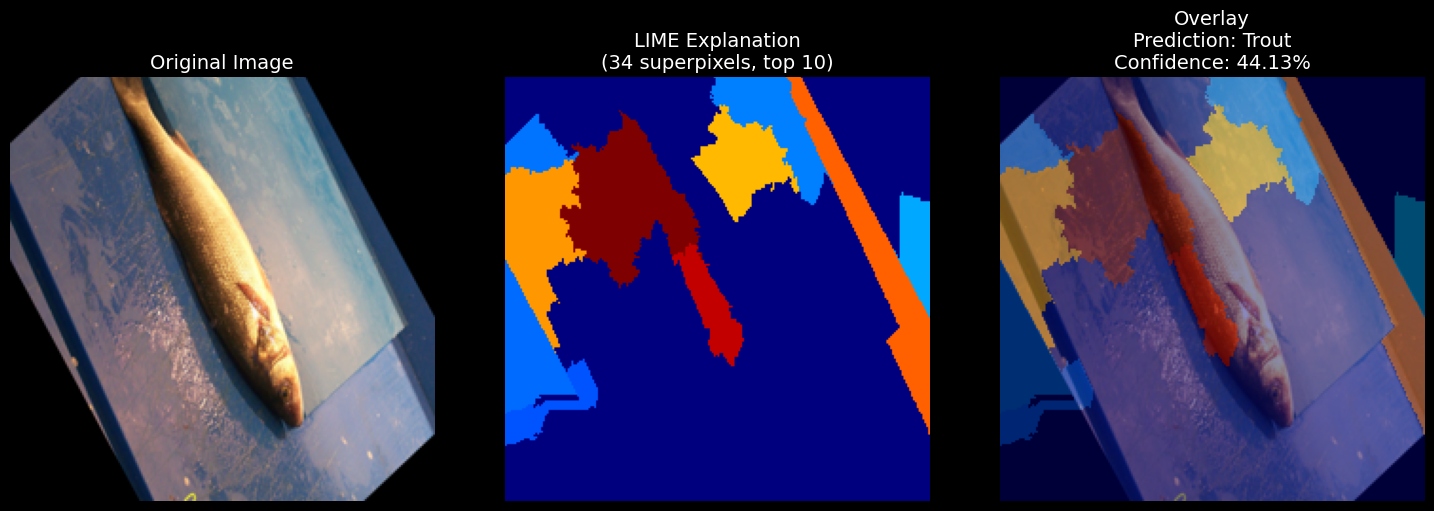

Explaining prediction for class: Sea Bass
Predicted: Trout (44.13%)
Created 34 superpixels
Generating 1000 perturbations...
Saved to images/lime_explanation.png


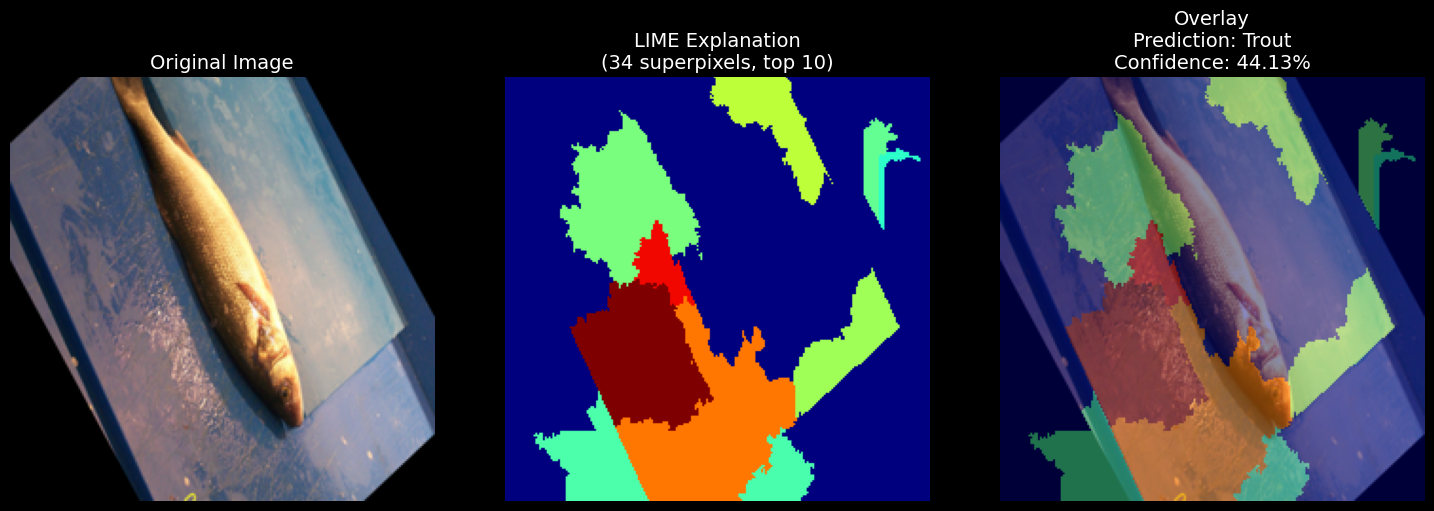

In [15]:
from lime_single_image_v3 import visualize_lime


# Single class LIME
img, mask, overlay, class_idx = visualize_lime(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    num_samples=1000,  # More samples = better but slower
    num_features=10,  # Number of superpixels to highlight
    save_path="images/lime_explanation.png",
)

img, mask, overlay, class_idx = visualize_lime(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    num_samples=1000,  # More samples = better but slower
    num_features=10,  # Number of superpixels to highlight
    save_path="images/lime_explanation.png",
    target_class_idx=CLASS_NAMES.index(img_path.split("/")[-3])

)

Predicted: Trout (class 8) prob=44.13%
Created 34 superpixels
Generating 500 perturbations for all classes...
  Processing class 0: Black Sea Sprat...
  Processing class 1: Gilt-Head Bream...
  Processing class 2: Hourse Mackerel...
  Processing class 3: Red Mullet...
  Processing class 4: Red Sea Bream...
  Processing class 5: Sea Bass...
  Processing class 6: Shrimp...
  Processing class 7: Striped Red Mullet...
  Processing class 8: Trout...
Saved to images/lime_all_classes.png


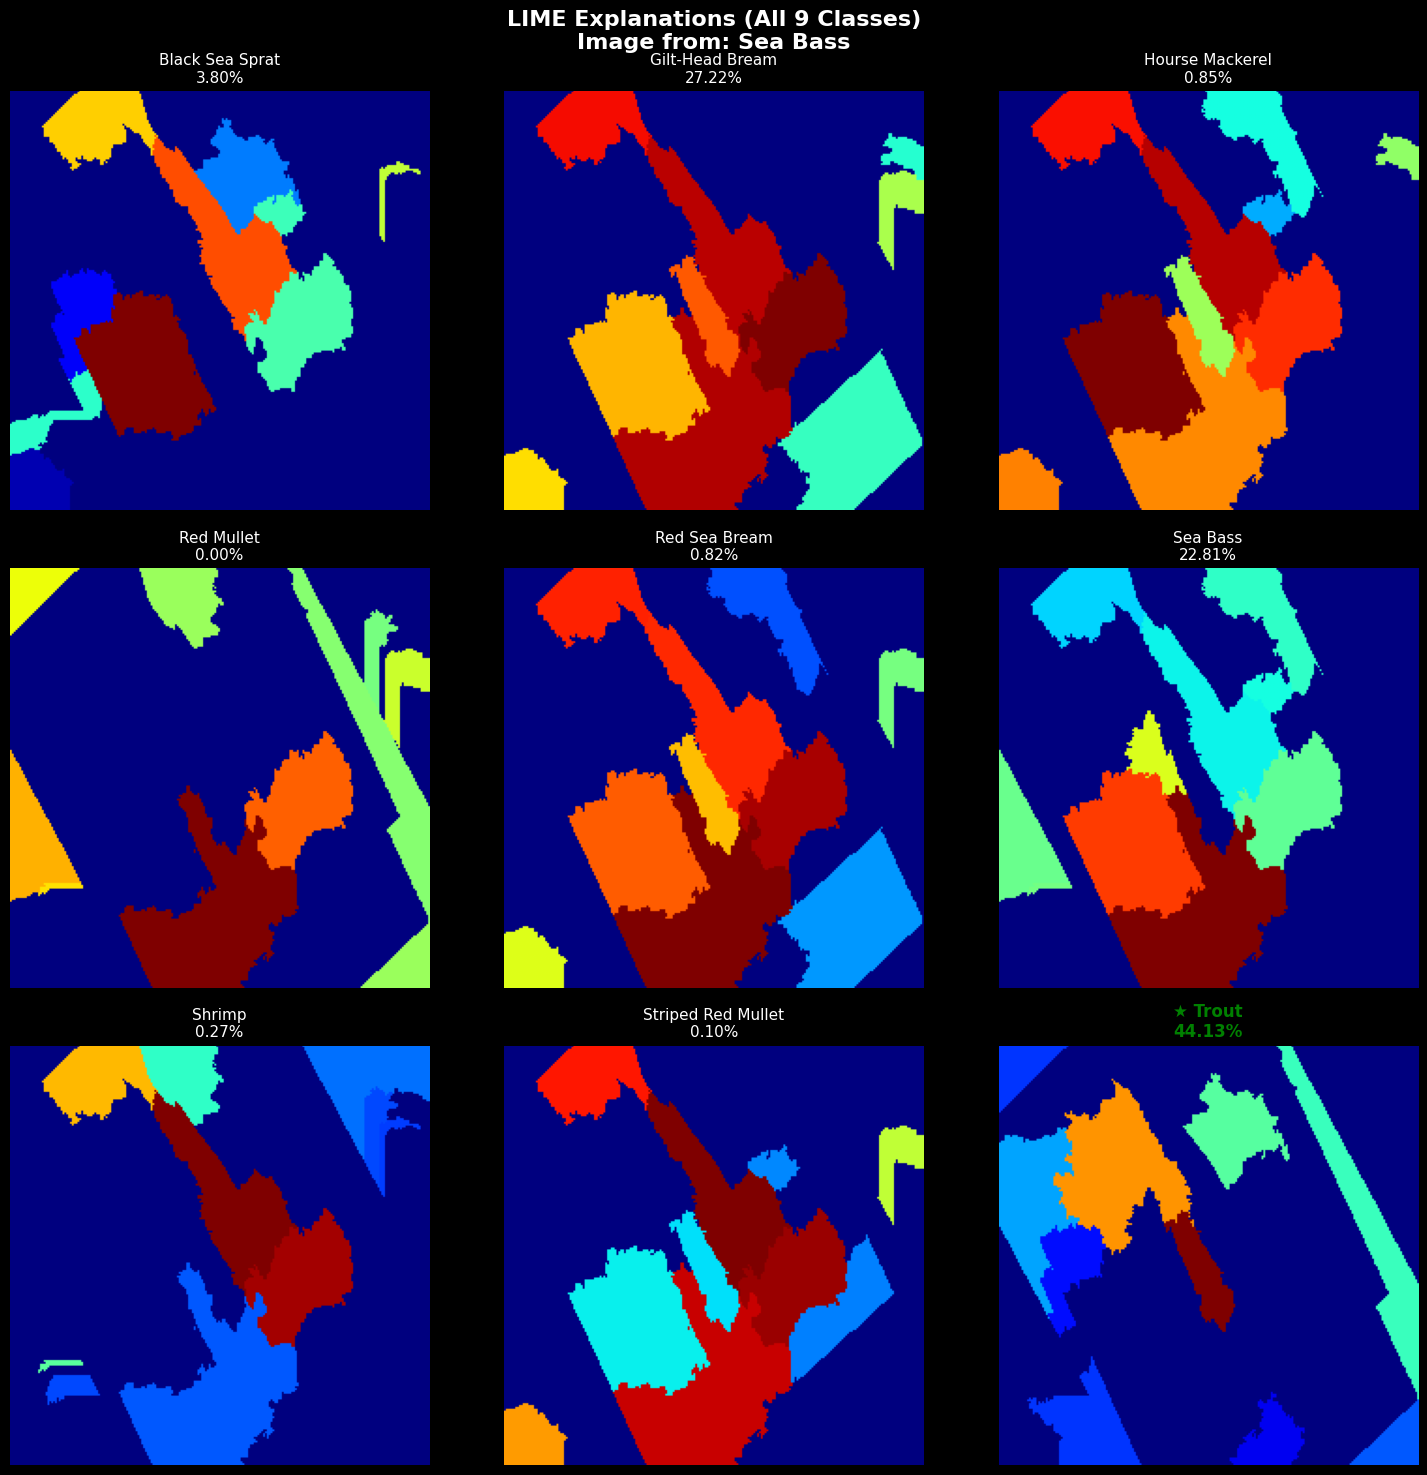


★ = Predicted class: Trout


In [16]:
from lime_all_classes_v3 import visualize_lime_all_classes
# All classes LIME (3x3 grid)
result = visualize_lime_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    num_samples=500,  # Lower for speed when doing 9 classes
    save_path="images/lime_all_classes.png"
)

# Occlusion Sensitivity

Analyzing occlusion sensitivity for class: Trout
Predicted: Trout (44.13%)
Baseline score for target class: 0.4413
Occluding with 28x28 patches, stride=14
Testing 225 positions...
  ... processed 50/225 patches
  ... processed 100/225 patches
  ... processed 150/225 patches
  ... processed 200/225 patches
Completed all 225 patches
Saved to images/occlusion_explanation.png


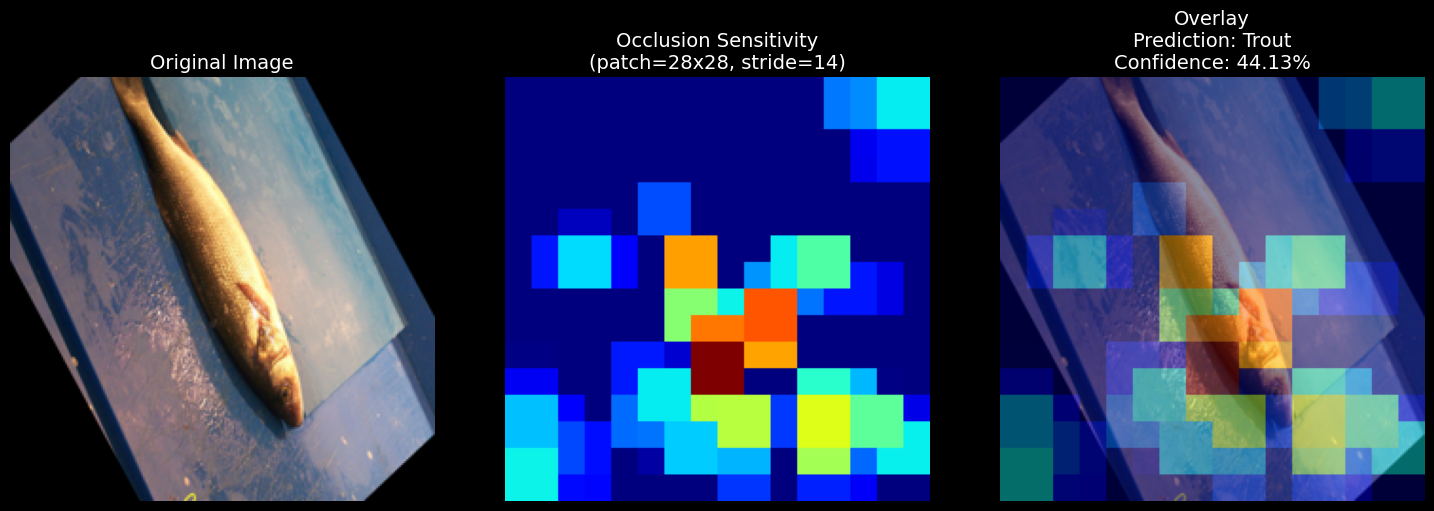

Predicted: Trout (class 8) prob=44.13%
Occluding with 28x28 patches, stride=28
Total positions to test: 64
Total forward passes: 64 (reused for all classes)
Pre-computing occlusions...
  ... processed 20/64 patches
  ... processed 40/64 patches
  ... processed 60/64 patches
  Processing class 0: Black Sea Sprat...
  Processing class 1: Gilt-Head Bream...
  Processing class 2: Hourse Mackerel...
  Processing class 3: Red Mullet...
  Processing class 4: Red Sea Bream...
  Processing class 5: Sea Bass...
  Processing class 6: Shrimp...
  Processing class 7: Striped Red Mullet...
  Processing class 8: Trout...
Saved to images/occlusion_all_classes.png


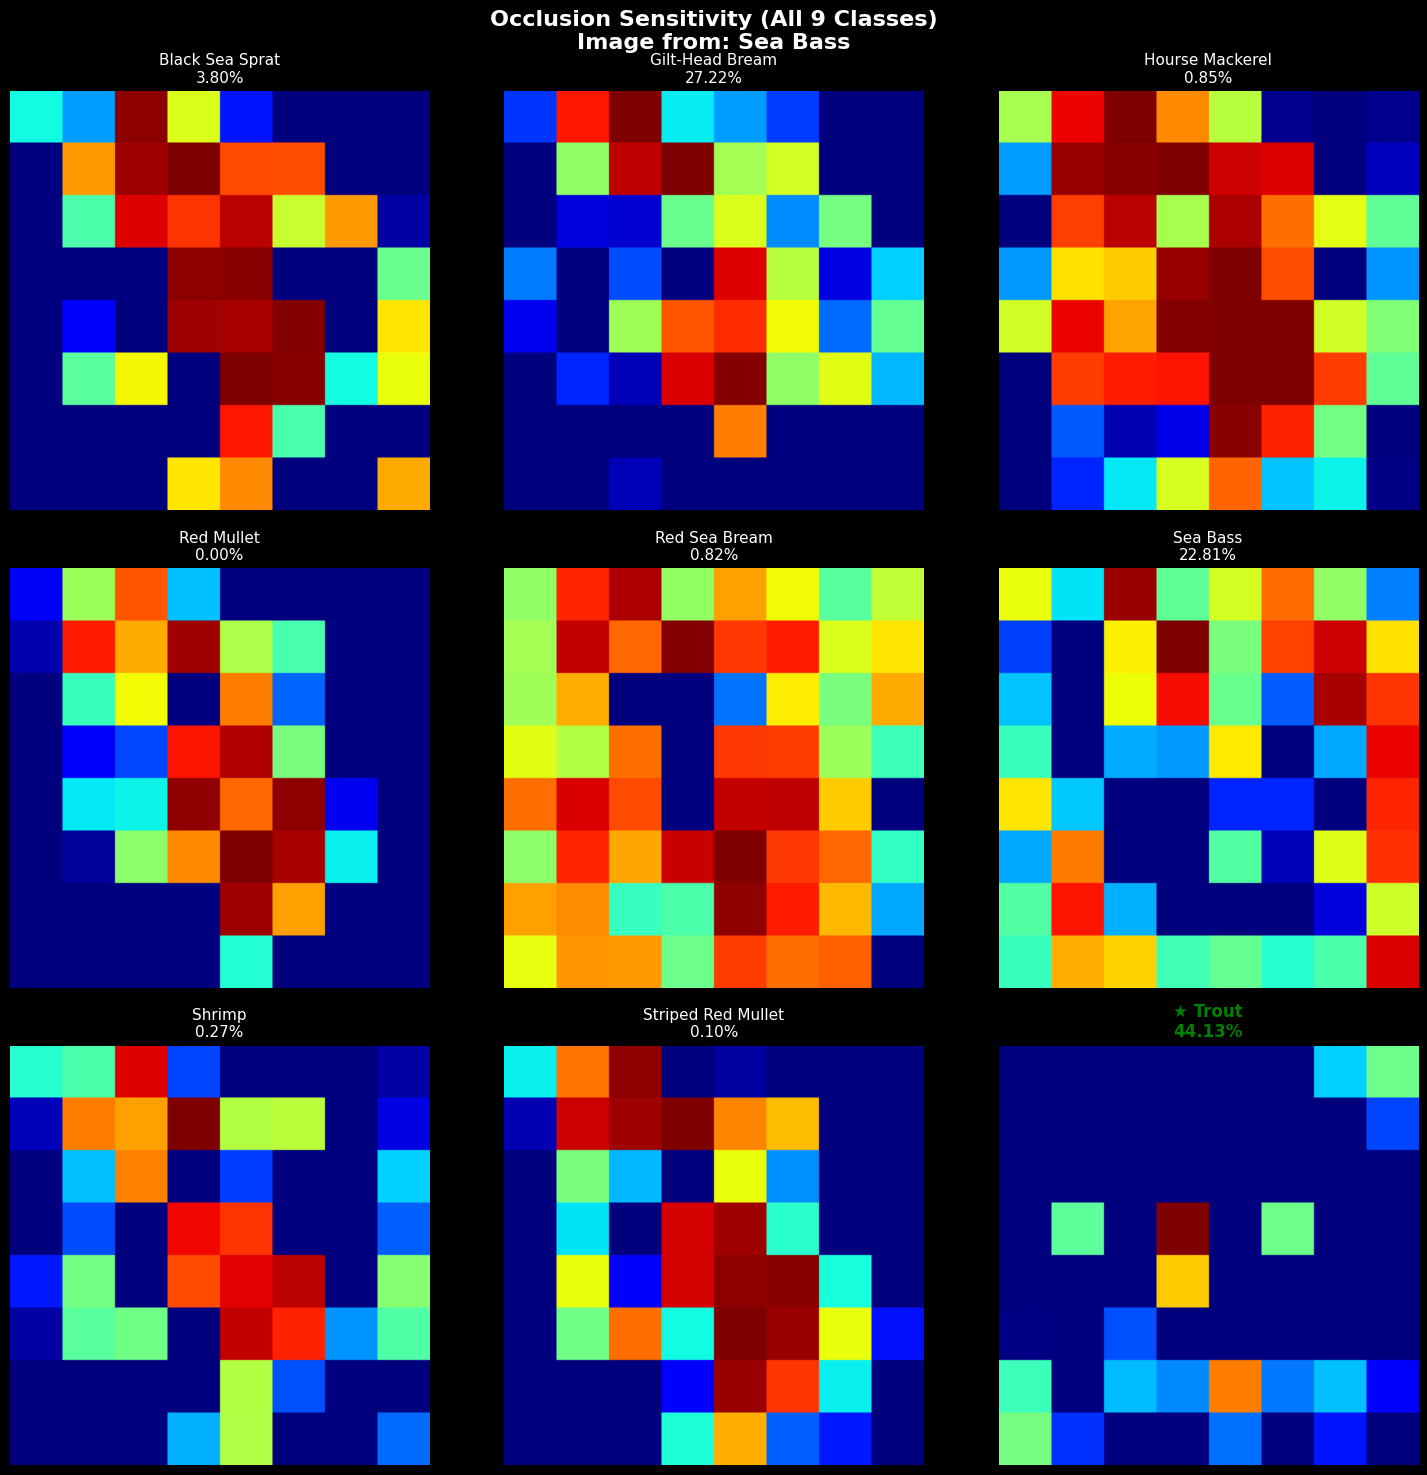


★ = Predicted class: Trout
true class:  Sea Bass
predicted class:  Trout


In [17]:
from occlusion_single_image_v3 import visualize_occlusion
from occlusion_all_classes_v3 import visualize_occlusion_all_classes

img, sensitivity_map, overlay, class_idx = visualize_occlusion(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    patch_size=28,  # Size of gray occlusion patch
    stride=14,  # How much to move patch each time (smaller = more precise but slower)
    save_path="images/occlusion_explanation.png"
)

# All classes Occlusion (3x3 grid)
result = visualize_occlusion_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    patch_size=28,
    stride=28,  # Use larger stride for speed (same as patch_size = no overlap)
    save_path="images/occlusion_all_classes.png"
)

print("true class: ", img_path.split("/")[-3])
print("predicted class: ", CLASS_NAMES[result['predicted_class']])